# Day 3 — Exploratory Data Analysis
## Bluestock Fintech Mutual Fund Analytics Capstone
**Objective:** Deep EDA on NAV, AUM, SIP and investor data with 15+ charts


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PROCESSED = Path('../data/processed')
REPORTS   = Path('../reports')
REPORTS.mkdir(exist_ok=True)

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
COLORS = px.colors.qualitative.Set2

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# Load all cleaned datasets
fm   = pd.read_csv(PROCESSED / 'clean_fund_master.csv', parse_dates=['launch_date'])
nav  = pd.read_csv(PROCESSED / 'clean_nav_history.csv', parse_dates=['nav_date'])
aum  = pd.read_csv(PROCESSED / 'clean_aum_by_fund_house.csv', parse_dates=['date'])
sip  = pd.read_csv(PROCESSED / 'clean_monthly_sip_inflows.csv', parse_dates=['month'])
cat  = pd.read_csv(PROCESSED / 'clean_category_inflows.csv', parse_dates=['month'])
fol  = pd.read_csv(PROCESSED / 'clean_industry_folio_count.csv', parse_dates=['month'])
perf = pd.read_csv(PROCESSED / 'clean_scheme_performance.csv')
tx   = pd.read_csv(PROCESSED / 'clean_investor_transactions.csv', parse_dates=['transaction_date'])
ph   = pd.read_csv(PROCESSED / 'clean_portfolio_holdings.csv')
bm   = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv', parse_dates=['date'])

print(f'nav      : {nav.shape[0]:,} rows')
print(f'tx       : {tx.shape[0]:,} rows')
print(f'benchmark: {bm.shape[0]:,} rows')
print('All datasets loaded ✅')

nav      : 46,000 rows
tx       : 32,778 rows
benchmark: 8,050 rows
All datasets loaded ✅


## Chart 1 — NAV Trend Lines (Top 10 Funds, 2022–2026)

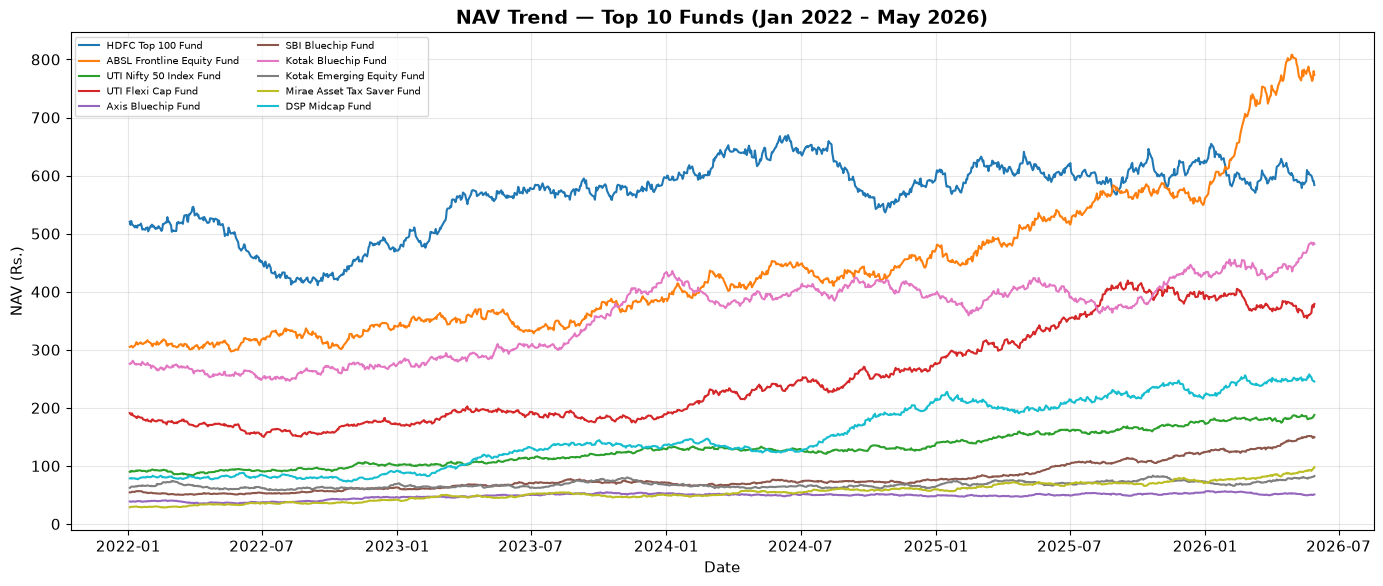

Chart 1 saved ✅


In [3]:
top10 = fm.nlargest(10, 'expense_ratio_pct')['amfi_code'].astype(str).tolist()
nav10 = nav[nav['amfi_code'].astype(str).isin(top10)].copy()
nav10 = nav10.merge(fm[['amfi_code','scheme_name']], on='amfi_code', how='left')
nav10['scheme_short'] = nav10['scheme_name'].str.split(' - ').str[0].str[:30]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (code, grp) in enumerate(nav10.groupby('amfi_code')):
    name = grp['scheme_short'].iloc[0]
    ax.plot(grp['nav_date'], grp['nav'], label=name, linewidth=1.5)

ax.set_title('NAV Trend — Top 10 Funds (Jan 2022 – May 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NAV (Rs.)')
ax.legend(fontsize=7, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(REPORTS / 'chart01_nav_trends.png', dpi=150)
plt.show()
print('Chart 1 saved ✅')

## Chart 2 — AUM Growth by Fund House (2022–2025)

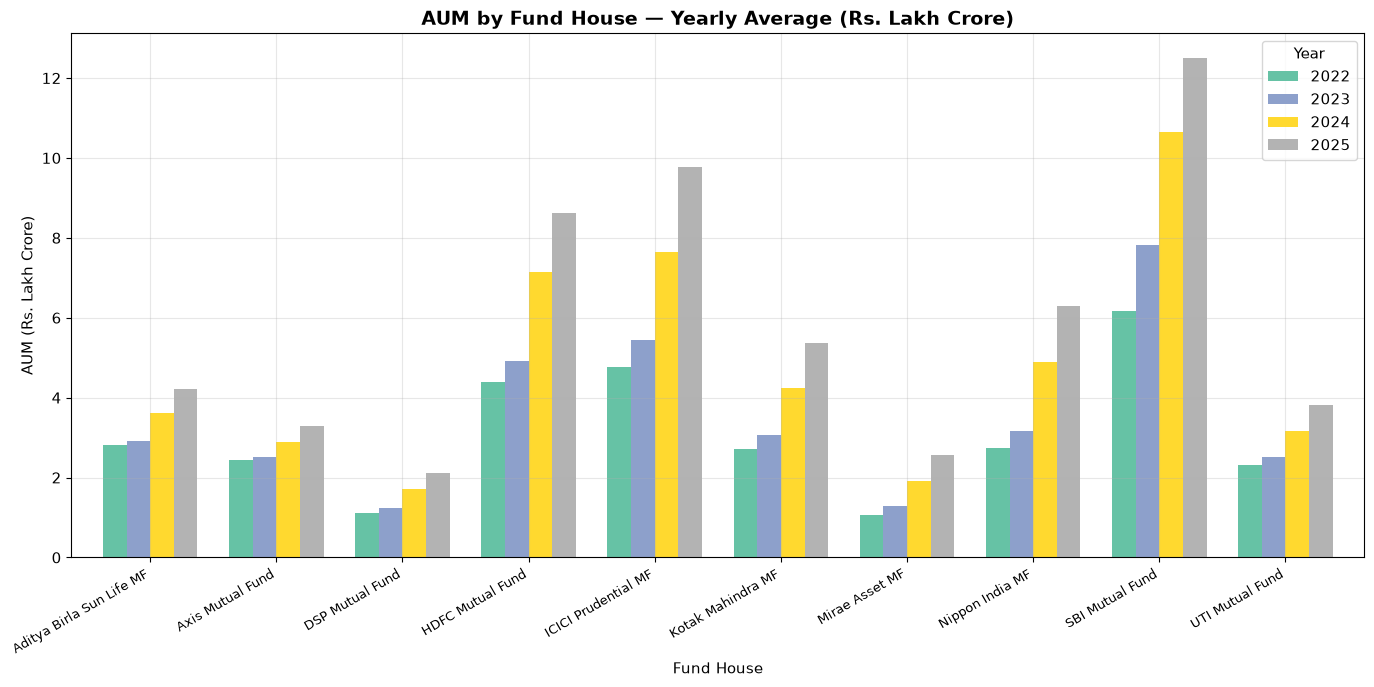

Chart 2 saved ✅


In [4]:
aum['year'] = aum['date'].dt.year
aum_yr = aum.groupby(['fund_house','year'])['aum_lakh_crore'].mean().reset_index()
aum_pivot = aum_yr.pivot(index='fund_house', columns='year', values='aum_lakh_crore').fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
aum_pivot.plot(kind='bar', ax=ax, width=0.75, colormap='Set2')
ax.set_title('AUM by Fund House — Yearly Average (Rs. Lakh Crore)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fund House')
ax.set_ylabel('AUM (Rs. Lakh Crore)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.legend(title='Year')
plt.tight_layout()
plt.savefig(REPORTS / 'chart02_aum_growth.png', dpi=150)
plt.show()
print('Chart 2 saved ✅')

## Chart 3 — SIP Inflow Time Series (Jan 2022 – Dec 2025)

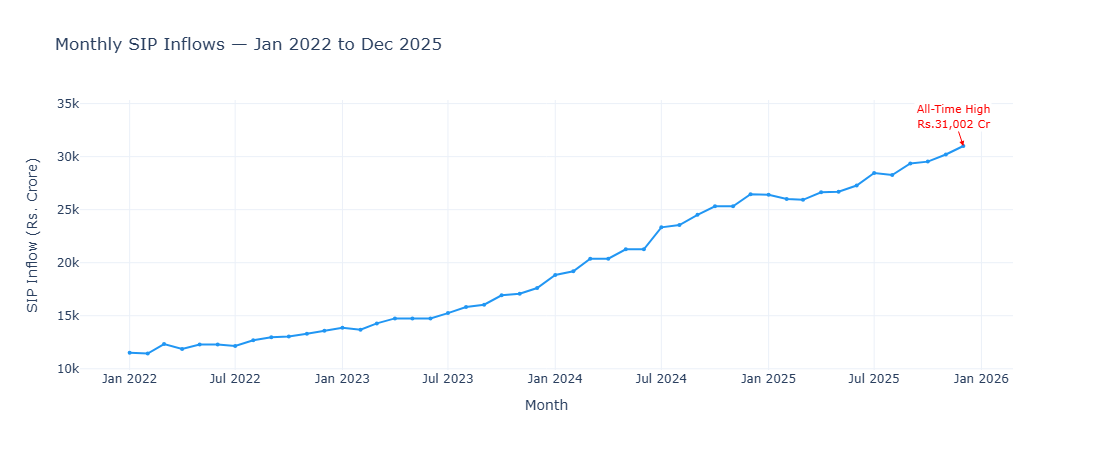

Chart 3 saved ✅


In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sip['month'], y=sip['sip_inflow_crore'],
    mode='lines+markers', name='SIP Inflow',
    line=dict(color='#2196F3', width=2),
    marker=dict(size=4)
))

# Mark the all-time high
ath = sip.loc[sip['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=ath['month'], y=ath['sip_inflow_crore'],
    text=f"All-Time High<br>Rs.{ath['sip_inflow_crore']:,} Cr",
    showarrow=True, arrowhead=2, arrowcolor='red',
    font=dict(color='red', size=11), bgcolor='white'
)

fig.update_layout(
    title='Monthly SIP Inflows — Jan 2022 to Dec 2025',
    xaxis_title='Month', yaxis_title='SIP Inflow (Rs. Crore)',
    height=450, template='plotly_white'
)
fig.write_html(str(REPORTS / 'chart03_sip_inflow.html'))
fig.show()
print('Chart 3 saved ✅')

## Chart 4 — Category Inflow Heatmap

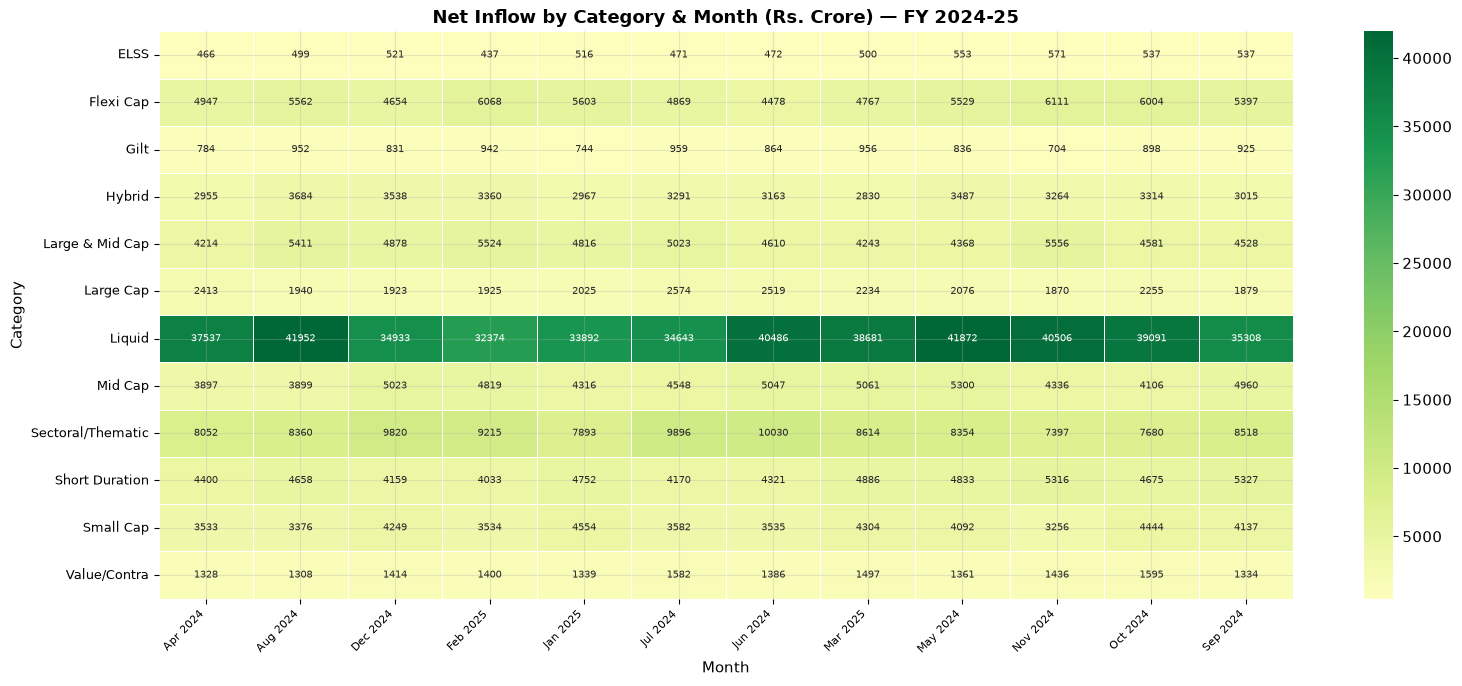

Chart 4 saved ✅


In [6]:
cat['month_str'] = cat['month'].dt.strftime('%b %Y')
pivot = cat.pivot(index='category', columns='month_str', values='net_inflow_crore')

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Net Inflow by Category & Month (Rs. Crore) — FY 2024-25',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS / 'chart04_category_heatmap.png', dpi=150)
plt.show()
print('Chart 4 saved ✅')

## Chart 5 — Investor Age Group Distribution

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart — age distribution
age_counts = tx['age_group'].value_counts().sort_index()
axes[0].pie(
    age_counts.values, labels=age_counts.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', len(age_counts))h
)
axes[0].set_title('Investor Age Group Distribution', fontweight='bold')

# Box plot — SIP amount by age group
sip_tx = tx[tx['transaction_type'] == 'Sip']
age_order = sorted(sip_tx['age_group'].unique())
sip_tx.boxplot(
    column='amount_inr', by='age_group',
    ax=axes[1],
    patch_artist=True
)
axes[1].set_title('SIP Amount Distribution by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (Rs.)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(REPORTS / 'chart05_age_demographics.png', dpi=150)
plt.show()
print('Chart 5 saved ✅')

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3410334630.py, line 8)

## Chart 6 — SIP Amount by State (Top 10) + T30 vs B30

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Horizontal bar — top 10 states by SIP amount
state_sip = tx[tx['transaction_type']=='Sip'].groupby('state')['amount_inr'].sum().nlargest(10)
state_sip.sort_values().plot(
    kind='barh', ax=axes[0],
    color=sns.color_palette('Blues_d', 10)
)
axes[0].set_title('Top 10 States by Total SIP Amount', fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (Rs.)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))

# Pie — T30 vs B30
tier_split = tx.groupby('city_tier')['amount_inr'].sum()
axes[1].pie(
    tier_split.values, labels=tier_split.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#42A5F5','#FFA726'],
    explode=[0.05, 0]
)
axes[1].set_title('T30 vs B30 City Investment Split', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / 'chart06_geo_distribution.png', dpi=150)
plt.show()
print('Chart 6 saved ✅')

## Chart 7 — Industry Folio Count Growth

In [ ]:
fig = go.Figure()
for col, color in zip(
    ['equity_folios_crore','debt_folios_crore','hybrid_folios_crore'],
    ['#1565C0','#E53935','#43A047']
):
    label = col.replace('_folios_crore','').title()
    fig.add_trace(go.Scatter(
        x=fol['month'], y=fol[col],
        name=label, mode='lines',
        line=dict(color=color, width=2),
        stackgroup='one'
    ))

fig.update_layout(
    title='Industry Folio Count Growth (Crore) — Jan 2022 to Dec 2025',
    xaxis_title='Month', yaxis_title='Folios (Crore)',
    height=420, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.write_html(str(REPORTS / 'chart07_folio_growth.html'))
fig.show()
print('Chart 7 saved ✅')

## Chart 8 — NAV Return Correlation Matrix (10 Funds)

In [ ]:
# Pick 10 funds with most NAV data
top10_codes = nav.groupby('amfi_code')['nav_date'].count().nlargest(10).index.astype(str)
nav_pivot = nav[nav['amfi_code'].astype(str).isin(top10_codes)].copy()
nav_pivot = nav_pivot.pivot(index='nav_date', columns='amfi_code', values='daily_return_pct')
nav_pivot.columns = [fm.set_index('amfi_code')['scheme_name'].get(int(c), str(c))[:20]
                     for c in nav_pivot.columns]
corr = nav_pivot.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=0, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('NAV Return Correlation Matrix — 10 Funds', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / 'chart08_correlation_matrix.png', dpi=150)
plt.show()
print('Chart 8 saved ✅')

## Chart 9 — Top Sector Allocation (Portfolio Holdings)

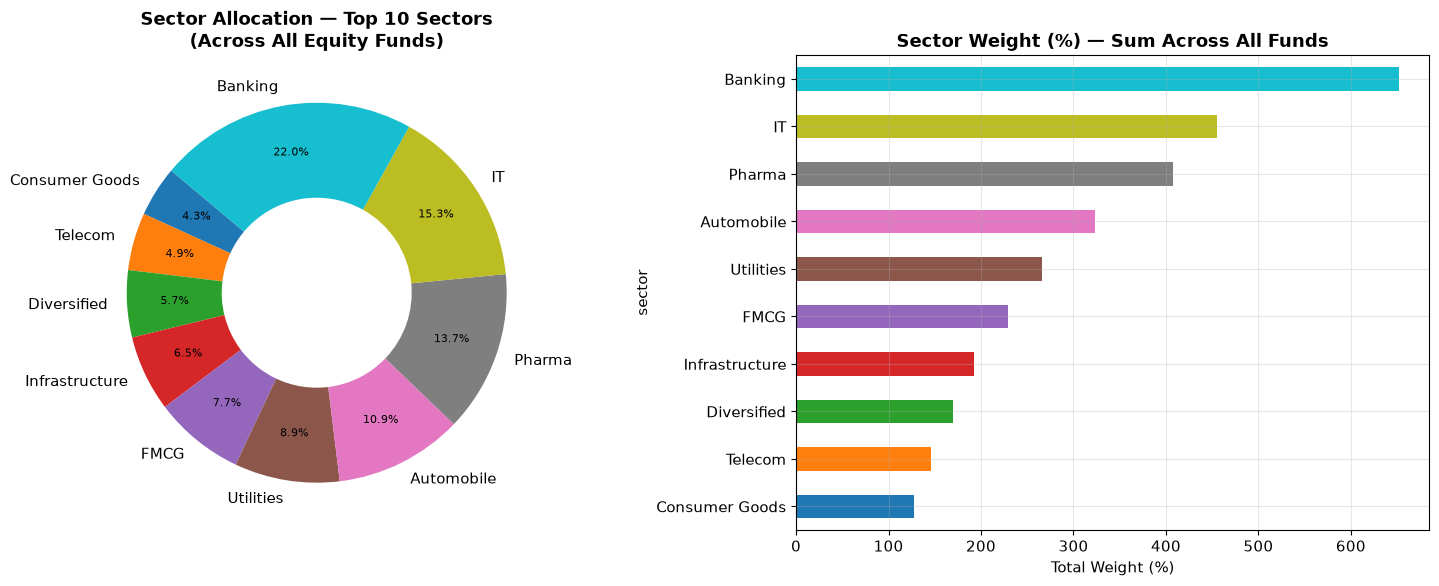

Chart 9 saved ✅


In [8]:
sector_wt = ph.groupby('sector')['weight_pct'].sum().nlargest(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    sector_wt.values, labels=sector_wt.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('tab10', len(sector_wt)),
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)
for at in autotexts: at.set_fontsize(8)
axes[0].set_title('Sector Allocation — Top 10 Sectors\n(Across All Equity Funds)', fontweight='bold')

# Horizontal bar
sector_wt.plot(kind='barh', ax=axes[1], color=sns.color_palette('tab10', len(sector_wt)))
axes[1].set_title('Sector Weight (%) — Sum Across All Funds', fontweight='bold')
axes[1].set_xlabel('Total Weight (%)')

plt.tight_layout()
plt.savefig(REPORTS / 'chart09_sector_allocation.png', dpi=150)
plt.show()
print('Chart 9 saved ✅')

## Chart 10 — Risk vs Return Scatter (All 40 Funds)

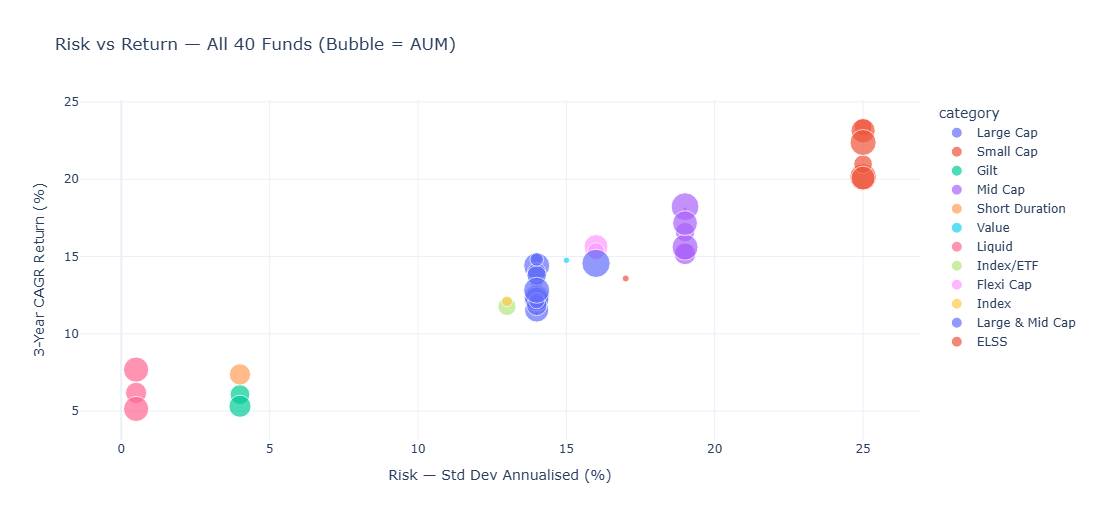

Chart 10 saved ✅


In [9]:
fig = px.scatter(
    perf, x='std_dev_ann_pct', y='return_3yr_pct',
    size='aum_crore', color='category',
    hover_name='scheme_name',
    hover_data={'sharpe_ratio': True, 'aum_crore': True},
    labels={
        'std_dev_ann_pct': 'Risk — Std Dev Annualised (%)',
        'return_3yr_pct':  '3-Year CAGR Return (%)',
        'aum_crore':       'AUM (Crore)'
    },
    title='Risk vs Return — All 40 Funds (Bubble = AUM)',
    template='plotly_white', height=520
)
fig.write_html(str(REPORTS / 'chart10_risk_return.html'))
fig.show()
print('Chart 10 saved ✅')

## Chart 11 — Top 5 Funds vs Nifty 50 Benchmark

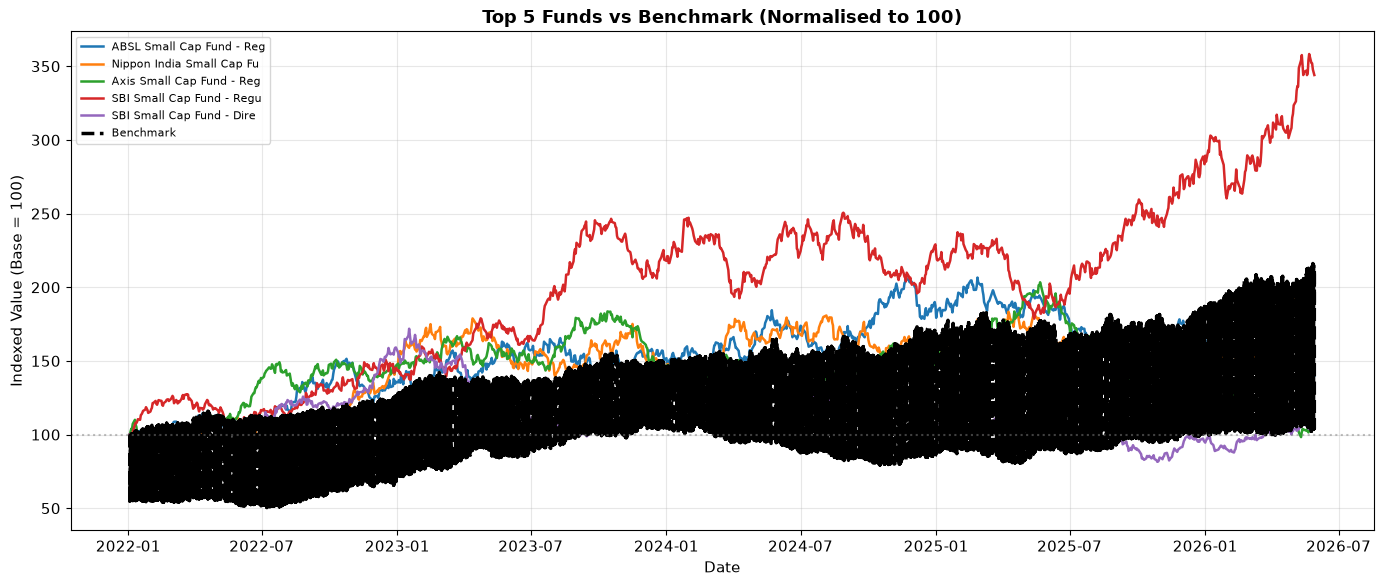

Chart 11 saved ✅


In [18]:
top5 = perf.nlargest(5, 'return_3yr_pct')
top5_codes = top5['amfi_code'].tolist()
nav5 = nav[nav['amfi_code'].isin(top5_codes)].copy()
nav5['scheme_label'] = nav5['amfi_code'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
for code, grp in nav5.groupby('amfi_code'):
    grp = grp.sort_values('nav_date')
    nav_norm = grp['nav'] / grp['nav'].iloc[0] * 100
    label = top5[top5['amfi_code']==code]['scheme_name'].values
    label = label[0][:25] if len(label) > 0 else str(code)
    ax.plot(grp['nav_date'], nav_norm, label=label, linewidth=1.8)

nifty = bm[bm['index_name'].str.upper().str.contains('NIFTY')].copy()
if not nifty.empty:
    nifty = nifty.sort_values('date')
    nav_norm = nifty['close_value'] / nifty['close_value'].iloc[0] * 100
    ax.plot(nifty['date'], nav_norm,
            label='Benchmark', linewidth=2.5,
            linestyle='--', color='black')

ax.axhline(100, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Top 5 Funds vs Benchmark (Normalised to 100)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Value (Base = 100)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / 'chart11_benchmark_comparison.png', dpi=150)
plt.show()
print('Chart 11 saved ✅')

## Chart 12 — Transaction Type Split by Gender

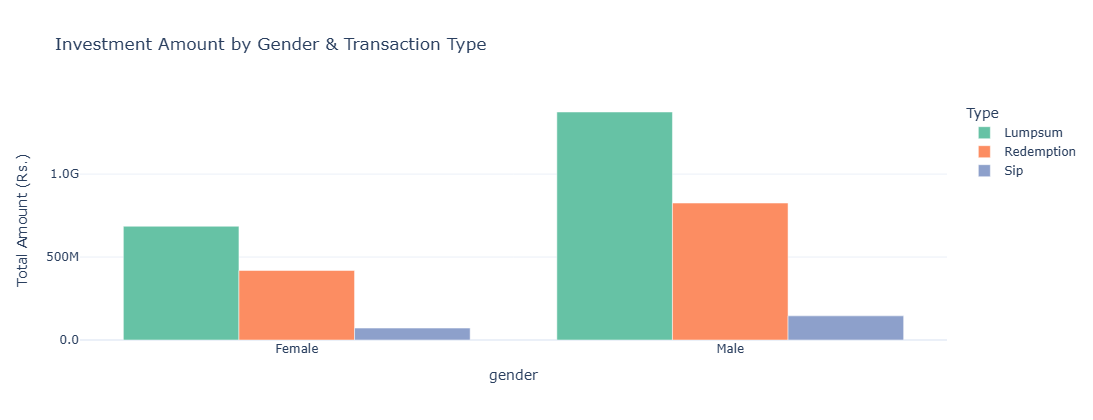

Chart 12 saved ✅


In [11]:
gender_tx = tx.groupby(['gender','transaction_type'])['amount_inr'].sum().reset_index()
fig = px.bar(
    gender_tx, x='gender', y='amount_inr',
    color='transaction_type', barmode='group',
    labels={'amount_inr':'Total Amount (Rs.)', 'transaction_type':'Type'},
    title='Investment Amount by Gender & Transaction Type',
    template='plotly_white', height=420,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_yaxes(tickformat='.2s')
fig.write_html(str(REPORTS / 'chart12_gender_tx.html'))
fig.show()
print('Chart 12 saved ✅')

## Chart 13 — Monthly Transaction Volume Trend

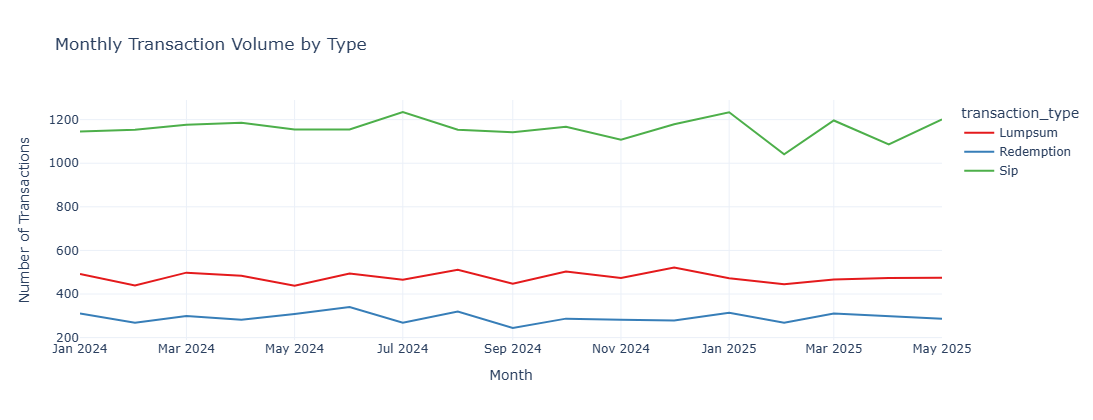

Chart 13 saved ✅


In [12]:
tx['month'] = tx['transaction_date'].dt.to_period('M').dt.to_timestamp()
monthly_vol = tx.groupby(['month','transaction_type']).size().reset_index(name='count')

fig = px.line(
    monthly_vol, x='month', y='count',
    color='transaction_type',
    title='Monthly Transaction Volume by Type',
    labels={'count':'Number of Transactions', 'month':'Month'},
    template='plotly_white', height=420,
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.write_html(str(REPORTS / 'chart13_monthly_volume.html'))
fig.show()
print('Chart 13 saved ✅')

## Chart 14 — Sharpe Ratio Ranking (All 40 Funds)

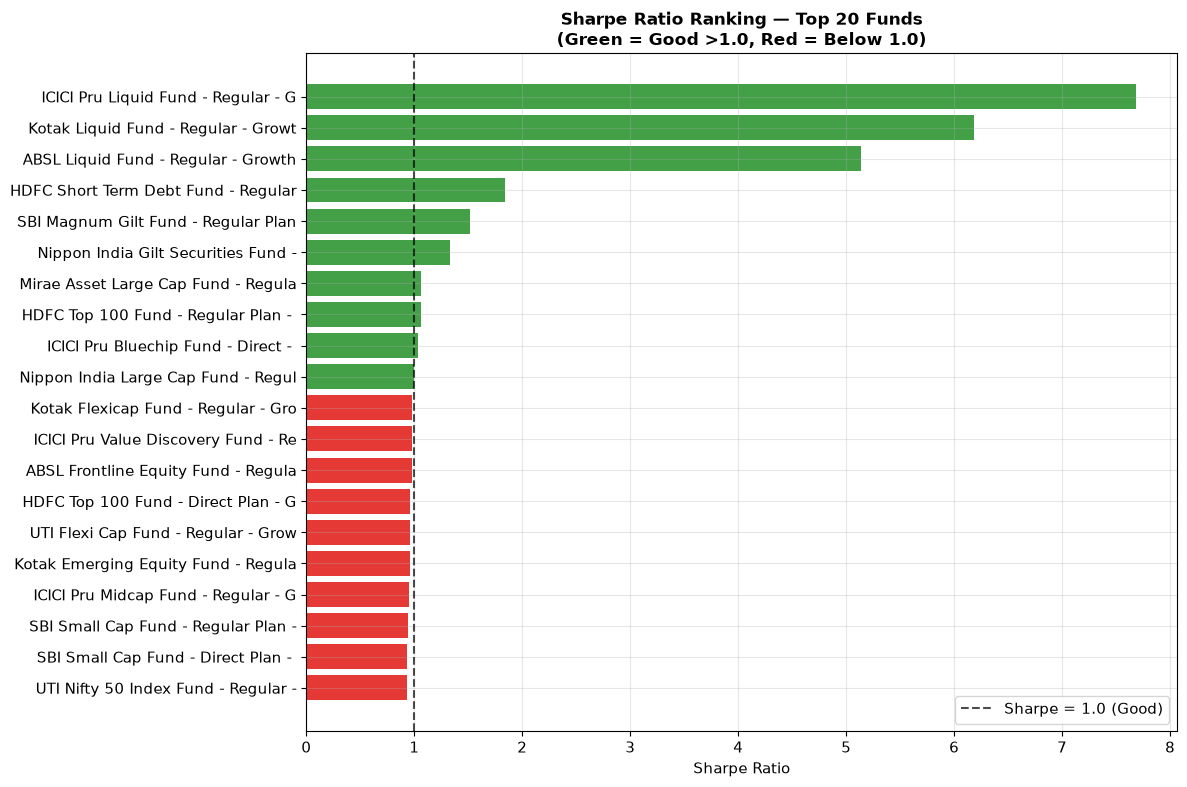

Chart 14 saved ✅


In [13]:
perf_sorted = perf.sort_values('sharpe_ratio', ascending=True).tail(20)
perf_sorted['scheme_short'] = perf_sorted['scheme_name'].str[:35]

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#E53935' if s < 1 else '#43A047' for s in perf_sorted['sharpe_ratio']]
bars = ax.barh(perf_sorted['scheme_short'], perf_sorted['sharpe_ratio'], color=colors)
ax.axvline(1.0, color='black', linestyle='--', alpha=0.7, label='Sharpe = 1.0 (Good)')
ax.set_title('Sharpe Ratio Ranking — Top 20 Funds\n(Green = Good >1.0, Red = Below 1.0)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'chart14_sharpe_ranking.png', dpi=150)
plt.show()
print('Chart 14 saved ✅')

## Chart 15 — SIP Account Growth vs SIP Inflow

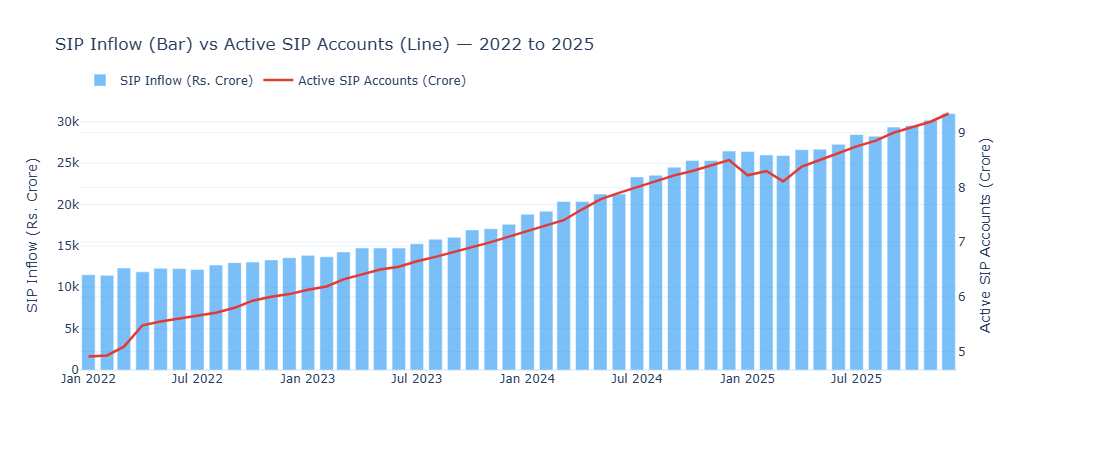

Chart 15 saved ✅


In [14]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(
    x=sip['month'], y=sip['sip_inflow_crore'],
    name='SIP Inflow (Rs. Crore)',
    marker_color='#42A5F5', opacity=0.7
), secondary_y=False)
fig.add_trace(go.Scatter(
    x=sip['month'], y=sip['active_sip_accounts_crore'],
    name='Active SIP Accounts (Crore)',
    line=dict(color='#E53935', width=2.5)
), secondary_y=True)

fig.update_layout(
    title='SIP Inflow (Bar) vs Active SIP Accounts (Line) — 2022 to 2025',
    template='plotly_white', height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.update_yaxes(title_text='SIP Inflow (Rs. Crore)', secondary_y=False)
fig.update_yaxes(title_text='Active SIP Accounts (Crore)', secondary_y=True)
fig.write_html(str(REPORTS / 'chart15_sip_dual_axis.html'))
fig.show()
print('Chart 15 saved ✅')

## EDA Key Findings

1. **NAV Growth:** All large-cap funds showed consistent upward trend 2022–2026 with a major rally in 2023-24.
2. **AUM Dominance:** SBI Mutual Fund leads with highest AUM, followed by ICICI Prudential and HDFC MF.
3. **SIP Milestone:** SIP inflows crossed an all-time high in Dec 2025 (Rs. 31,002 Cr), driven by strong retail participation.
4. **Category Trends:** Large Cap and Flexi Cap categories consistently attract highest net inflows; Debt categories show outflows during high-rate periods.
5. **Folio Growth:** Total industry folios doubled from ~13 Cr (2022) to ~26 Cr (Dec 2025), led by equity folios.
6. **Investor Demographics:** Age group 26-35 dominates SIP investments; SIP amounts increase with age group.
7. **Geographic Spread:** T30 cities contribute ~70%+ of total investment; Maharashtra and Karnataka are top states.
8. **Correlation:** Large-cap funds show high positive correlation (>0.85) — diversification benefits are limited within the category.
9. **Sector Concentration:** Financial Services and IT dominate portfolio holdings across most equity funds.
10. **Sharpe Ratio:** Most funds have Sharpe >0.8, indicating good risk-adjusted returns. Top performers exceed 1.2.
